In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
!pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 187.9 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 407.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     ------------------------------ ------- 102.4/127.4 kB 3.0 MB/s eta 0:00:01
     -------------------------------------- 127.4/127.4 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.1/9.3 MB 7.5 MB/s eta 0:00:02
   - -------------------------------------- 0.3/9.3 MB 3.2 MB/s eta 0:00:03
   - -----------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
!pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   -- ------------------------------------ 20.5/294.9 kB 222.6 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 393.8 kB/s eta 0:00:01
   ------------------- -------------------- 143.4/294.9 kB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df=pd.read_csv("drug200.csv")

In [10]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [14]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


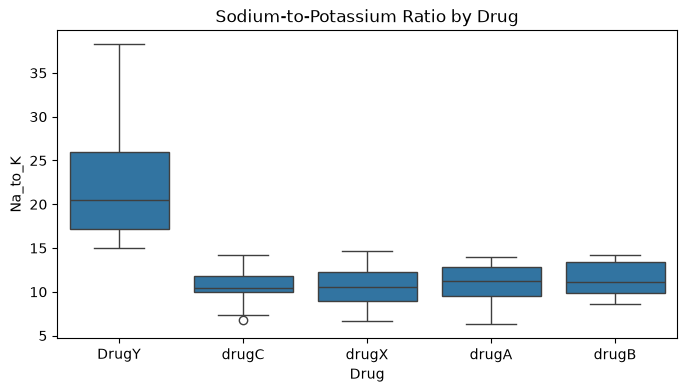

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Drug", y="Na_to_K", data=df)
plt.title("Sodium-to-Potassium Ratio by Drug")
plt.show()

In [21]:
bp_map = {"LOW": 0, "NORMAL": 1, "HIGH": 2}
chol_map = {"NORMAL": 0, "HIGH": 1}
sex_map = {"F": 0, "M": 1}

In [22]:
df["BP"] = df["BP"].map(bp_map)
df["Cholesterol"] = df["Cholesterol"].map(chol_map)
df["Sex"] = df["Sex"].map(sex_map)

In [23]:
# Split features and target
X = df.drop("Drug", axis=1)
y = df["Drug"]

In [27]:
!pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 465.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 991.0 kB/s eta 0:00:09
   ---------------------------------------- 0.1/8.3 MB 1.3 MB/s eta 0:00:07
    --------------------------------------- 0.2/8.3 MB 1.3 MB/s eta 0:00:07
    --------------------------------------- 0.2/8.3 MB 1.1 MB/s eta 0:00:08
    --------------------------------------- 0.2/8.3 MB 1.1 MB/s eta 0:00:08
    --------------------------------------- 0.2/8.3 MB 778.2 kB/s eta 0:00:11
   - -------------------------------------- 0.2/8.3 MB 801.7 kB/s eta 0:00:11
   - -----------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# Encode target
from sklearn.preprocessing import LabelEncoder

In [30]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [32]:
# Standardize numerical features for distance- and gradient-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

In [36]:
for name, model in models.items():
  # Fit with scaled features for scale-sensitive models
  if name in ["Logistic Regression", "KNN", "SVC"]:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

  score = f1_score(y_test, preds, average="weighted")
  print(f"{name} Weighted F1-Score: {score:.4f}")

Logistic Regression Weighted F1-Score: 1.0000
KNN Weighted F1-Score: 0.6731
SVC Weighted F1-Score: 0.9463
Decision Tree Weighted F1-Score: 0.9747
Random Forest Weighted F1-Score: 0.9747


C:\Users\sauro\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



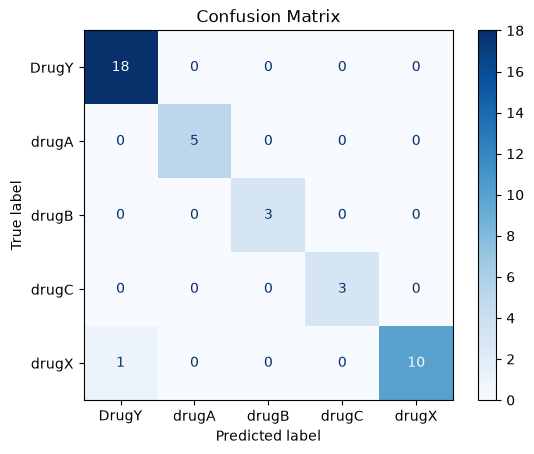

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Detailed per-class precision, recall, and F1-score
print(classification_report(y_test, preds, target_names=le.classes_))

# Visual Confusion Matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [39]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

       Feature  Importance
4      Na_to_K    0.560102
2           BP    0.240422
0          Age    0.127121
3  Cholesterol    0.056137
1          Sex    0.016217


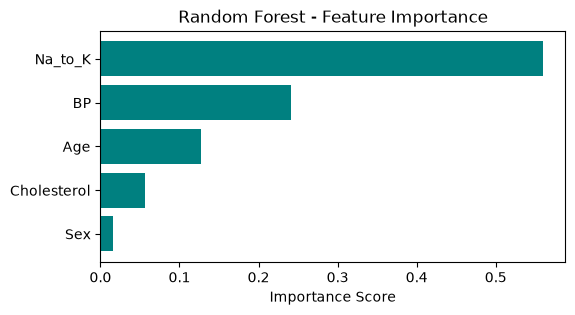

In [40]:
# Get importances from trained Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(
    by="Importance", ascending=False
)

print(feat_df)

# Plot feature importance
plt.figure(figsize=(6, 3))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [42]:
dt_model = models["Decision Tree"]

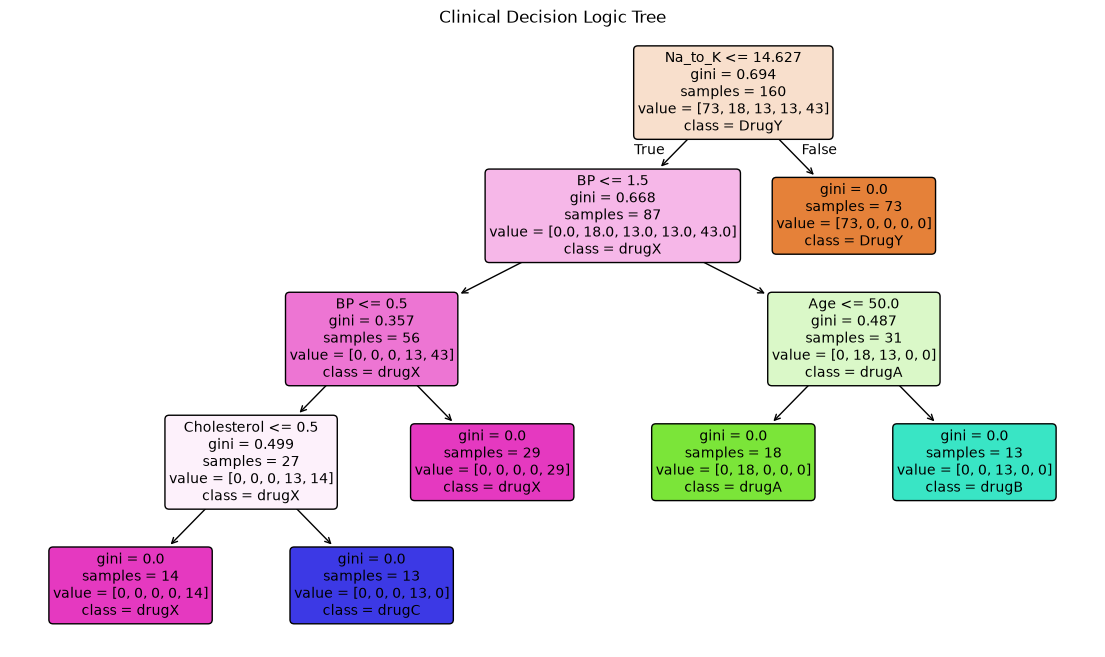

In [43]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Clinical Decision Logic Tree")
plt.show()

In [44]:
import joblib

# Bundle the model and the label encoder into a single dictionary
model_payload = {
    'model': rf_model,        # or dt_model
    'label_encoder': le,
    'feature_names': list(X.columns)
}

# Save to a file
joblib.dump(model_payload, 'drug_classifier_pipeline.pkl')
print("Model pipeline successfully saved to disk as 'drug_classifier_pipeline.pkl'")

Model pipeline successfully saved to disk as 'drug_classifier_pipeline.pkl'


In [45]:
# 1. Load the saved pipeline
saved_pipeline = joblib.load('drug_classifier_pipeline.pkl')
model = saved_pipeline['model']
le = saved_pipeline['label_encoder']

In [48]:
# 2. Define the categorical mappings used during training
bp_map = {"LOW": 0, "NORMAL": 1, "HIGH": 2}
chol_map = {"NORMAL": 0, "HIGH": 1}
sex_map = {"F": 0, "M": 1}

def predict_drug(age, sex, bp, cholesterol, na_to_k):
    """
    Takes raw patient input and returns the predicted drug.
    """
    # Build single-row DataFrame matching training feature names and order
    patient_data = pd.DataFrame([{
        'Age': age,
        'Sex': sex_map[sex.upper()],
        'BP': bp_map[bp.upper()],
        'Cholesterol': chol_map[cholesterol.upper()],
        'Na_to_K': na_to_k
    }])
    # Predict numeric class index
    pred_idx = model.predict(patient_data)[0]
    # Predict probabilities across all classes
    pred_probs = model.predict_proba(patient_data)[0]
    
    # Convert index back to original drug name
    predicted_drug = le.inverse_transform([pred_idx])[0]
    
    # Display results
    print(f"--- Prediction Results ---")
    print(f"Recommended Prescription: {predicted_drug}")
    print(f"Confidence: {pred_probs[pred_idx] * 100:.2f}%")
    print("\nClass Probabilities:")
    for drug_name, prob in zip(le.classes_, pred_probs):
        print(f"  {drug_name}: {prob * 100:.2f}%")
        
    return predicted_drug

In [49]:
# Test Case 1: High Na_to_K ratio (should predict DrugY)
print("Patient 1:")
predict_drug(age=35, sex='M', bp='HIGH', cholesterol='NORMAL', na_to_k=23.4)

print("\n" + "="*40 + "\n")

# Test Case 2: Older patient (>50) with High BP and low Na_to_K (should predict drugB)
print("Patient 2:")
predict_drug(age=62, sex='F', bp='HIGH', cholesterol='HIGH', na_to_k=9.8)

print("\n" + "="*40 + "\n")

# Test Case 3: Younger patient (<=50) with High BP and low Na_to_K (should predict drugA)
print("Patient 3:")
predict_drug(age=28, sex='M', bp='HIGH', cholesterol='NORMAL', na_to_k=11.2)

Patient 1:
--- Prediction Results ---
Recommended Prescription: DrugY
Confidence: 99.00%

Class Probabilities:
  DrugY: 99.00%
  drugA: 1.00%
  drugB: 0.00%
  drugC: 0.00%
  drugX: 0.00%


Patient 2:
--- Prediction Results ---
Recommended Prescription: drugB
Confidence: 79.00%

Class Probabilities:
  DrugY: 3.00%
  drugA: 7.00%
  drugB: 79.00%
  drugC: 0.00%
  drugX: 11.00%


Patient 3:
--- Prediction Results ---
Recommended Prescription: drugA
Confidence: 99.00%

Class Probabilities:
  DrugY: 0.00%
  drugA: 99.00%
  drugB: 1.00%
  drugC: 0.00%
  drugX: 0.00%


'drugA'